### 대선 자료 시각화

In [2]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import pandas as pd

In [3]:
# Data 불러오기
election = pd.read_csv("../Data/21대_대통령선거.csv")
election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석
0,서울특별시,종로구,125901,99261,47735,39574,9326
1,서울특별시,중구,110181,87166,40482,36302,8450
2,서울특별시,용산구,183614,143813,58705,67927,13794
3,서울특별시,성동구,244536,196282,88028,84043,20217
4,서울특별시,광진구,301007,239807,114304,94752,25469


In [4]:
election.tail()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석
248,경상남도,산청군,30968,24668,7478,15548,1130
249,경상남도,거창군,52316,41373,12623,25259,2640
250,경상남도,합천군,37329,28935,7001,20132,1188
251,제주특별자치도,제주시,409912,306685,169119,102224,27522
252,제주특별자치도,서귀포시,155343,114891,59610,43066,9387


In [5]:
# 기본 통계량 확인
election.describe()

,선거인수,투표수,이재명,김문수,이준석
count,253.000000,253.000000,253.000000,253.000000,253.000000
mean,175461.940711,139274.691700,68330.090909,56899.758893,11531.711462
std,135904.618790,108051.027945,57651.478345,47983.374559,10570.967359
min,8412.000000,6716.000000,1814.000000,1584.000000,454.000000
25%,50638.000000,38724.000000,18860.000000,16673.000000,2045.000000
50%,153669.000000,114891.000000,55305.000000,45028.000000,9057.000000
75%,263759.000000,216261.000000,106747.000000,90041.000000,18088.000000
max,617951.000000,484777.000000,261539.000000,246446.000000,46194.000000


In [6]:
# 컬럼명 확인
election.columns

Index(['광역시도', '시군구', '선거인수', '투표수', '이재명', '김문수', '이준석'], dtype='object')

In [7]:
# 데이터 크기
election.shape

(253, 7)

In [8]:
# 자료형 확인하기
election.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   광역시도    253 non-null    object
 1   시군구     253 non-null    object
 2   선거인수    253 non-null    int64 
 3   투표수     253 non-null    int64 
 4   이재명     253 non-null    int64 
 5   김문수     253 non-null    int64 
 6   이준석     253 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 14.0+ KB


In [18]:
# electionSum이라는 컬럼을 추가 : 이재명, 김문수, 이준석의 표의 합계

election['electionSum'] = election.loc[:,'이재명':'이준석'].sum(axis='columns')
election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum
0,서울특별시,종로구,125901,99261,47735,39574,9326,96635
1,서울특별시,중구,110181,87166,40482,36302,8450,85234
2,서울특별시,용산구,183614,143813,58705,67927,13794,140426
3,서울특별시,성동구,244536,196282,88028,84043,20217,192288
4,서울특별시,광진구,301007,239807,114304,94752,25469,234525


In [22]:
# electionSum이 투표수 대비 몇 퍼센트?
election['electionRatio'] = round(election.electionSum / election.투표수 * 100, 2)
election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
0,서울특별시,종로구,125901,99261,47735,39574,9326,96635,97.35
1,서울특별시,중구,110181,87166,40482,36302,8450,85234,97.78
2,서울특별시,용산구,183614,143813,58705,67927,13794,140426,97.64
3,서울특별시,성동구,244536,196282,88028,84043,20217,192288,97.97
4,서울특별시,광진구,301007,239807,114304,94752,25469,234525,97.80


In [25]:
# 3명을 지지한 투표율이 높은 지역 찾기
election[election.electionRatio == election.electionRatio.max()]

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
49,대구광역시,군위군,21402,17745,2616,14246,674,17536,98.82


In [26]:
# 기타후보를 제일 많이 지지한 지역 찾기
election[election.electionRatio == election.electionRatio.min()]

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
13,서울특별시,마포구,321302,260533,125049,101016,26948,253013,97.11


In [28]:
# 선거인수가 제일 많은 지역은?
election[election.선거인수 == election.선거인수.max()]

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
101,경기도,남양주시,617951,484777,261539,179144,36668,477351,98.47


In [29]:
# 투표수가 제일 많은 지역은?
election[election.투표수 == election.투표수.max()]

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
101,경기도,남양주시,617951,484777,261539,179144,36668,477351,98.47


In [30]:
# 투표수가 제일 적은 지역은?
election[election.투표수 == election.투표수.min()]

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
208,경상북도,울릉군,8412,6716,1814,4351,454,6619,98.56


In [31]:
# csv로 저장하기
election.to_csv("../Data/election_2025_V1.csv", index=False)

---
### 후보별 득표수 합계를 구하여 데이터셋 만들기

In [34]:
# 후보별 합계
candidate_totals = election.loc[:,'이재명':'이준석'].sum(axis='rows')
candidate_totals

이재명    17287513
김문수    14395639
이준석     2917523
dtype: int64

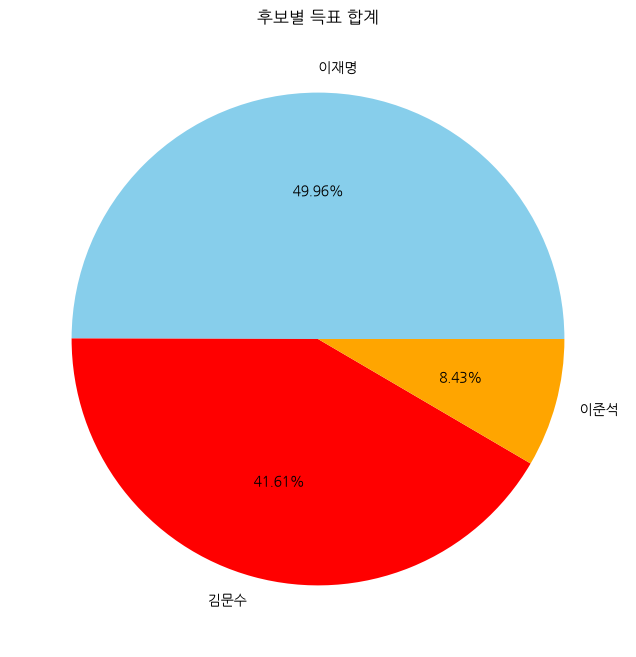

In [38]:
# 후보별 합계를 파이차트로 시각화
candidate_totals.plot(
    kind='pie',
    autopct = '%.2f%%',
    figsize=(8,8),
    colors = ['skyblue', 'red', 'orange']
)

plt.title('후보별 득표 합계')
plt.show()

----
#### 광역시별 투표율을 Pie Chart로 표현하기

In [39]:
election.head()

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
0,서울특별시,종로구,125901,99261,47735,39574,9326,96635,97.35
1,서울특별시,중구,110181,87166,40482,36302,8450,85234,97.78
2,서울특별시,용산구,183614,143813,58705,67927,13794,140426,97.64
3,서울특별시,성동구,244536,196282,88028,84043,20217,192288,97.97
4,서울특별시,광진구,301007,239807,114304,94752,25469,234525,97.80


In [41]:
# pivot을 이용하여 광역시별 투표수의 합계로 그룹화 집계한다.
elec_sum = \
	election.pivot_table(
		"투표수",
		index='광역시도',
		aggfunc='sum'
	)
elec_sum.head()

,투표수
광역시도,
강원특별자치도,1029407
경기도,9297448
경상남도,2179989
경상북도,1747364
광주광역시,1002149


In [43]:
# group by를 이용하여 광역시별 투표수를 합계로 그룹화 하여 집계
election.groupby('광역시도')['투표수'].sum().to_frame()

,투표수
광역시도,
강원특별자치도,1029407
경기도,9297448
경상남도,2179989
경상북도,1747364
광주광역시,1002149
대구광역시,1643051
대전광역시,977609
부산광역시,2245755
서울특별시,6641606


In [45]:
# 투표수별 순차를 내림차순으로 정렬
elec_sum_order = \
	elec_sum.sort_values(
		by='투표수',
		ascending=False
	)
elec_sum_order.head()

,투표수
광역시도,
경기도,9297448
서울특별시,6641606
부산광역시,2245755
경상남도,2179989
인천광역시,2035355


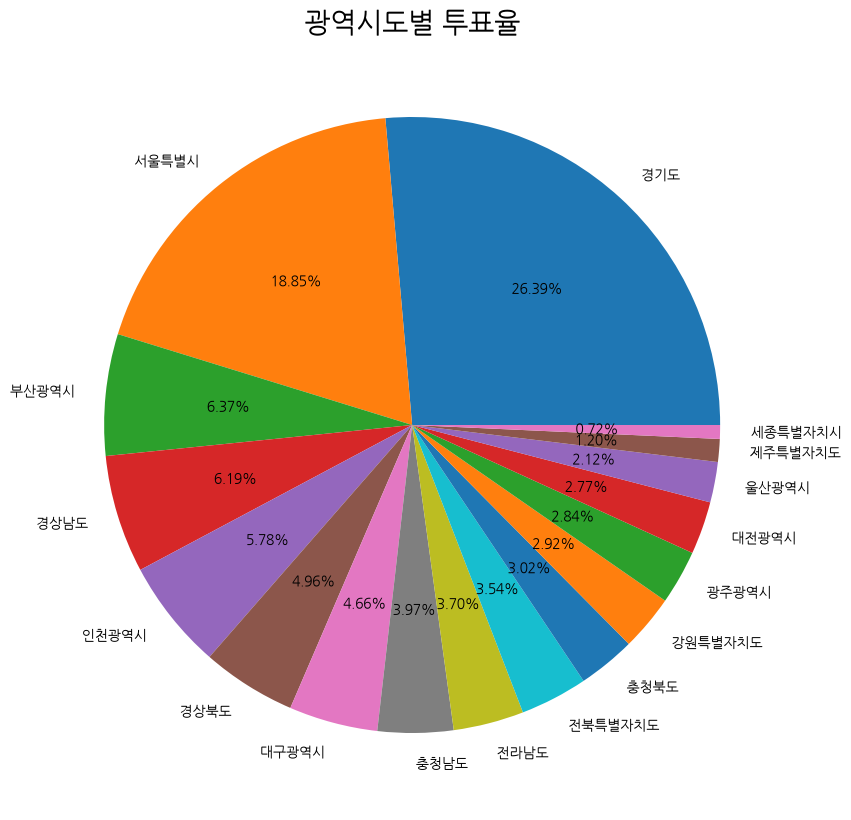

In [49]:
# 광역시도별 투표율

elec_sum_order.투표수.plot(
    kind='pie',
    figsize=(10, 10),
    autopct='%.2f%%'
)

plt.title('광역시도별 투표율', size=20)
plt.ylabel("")
plt.savefig("../Data/광역시도별_투표율.png")
plt.show()

---
#### 이재명 후보의 광역시도별 득표율

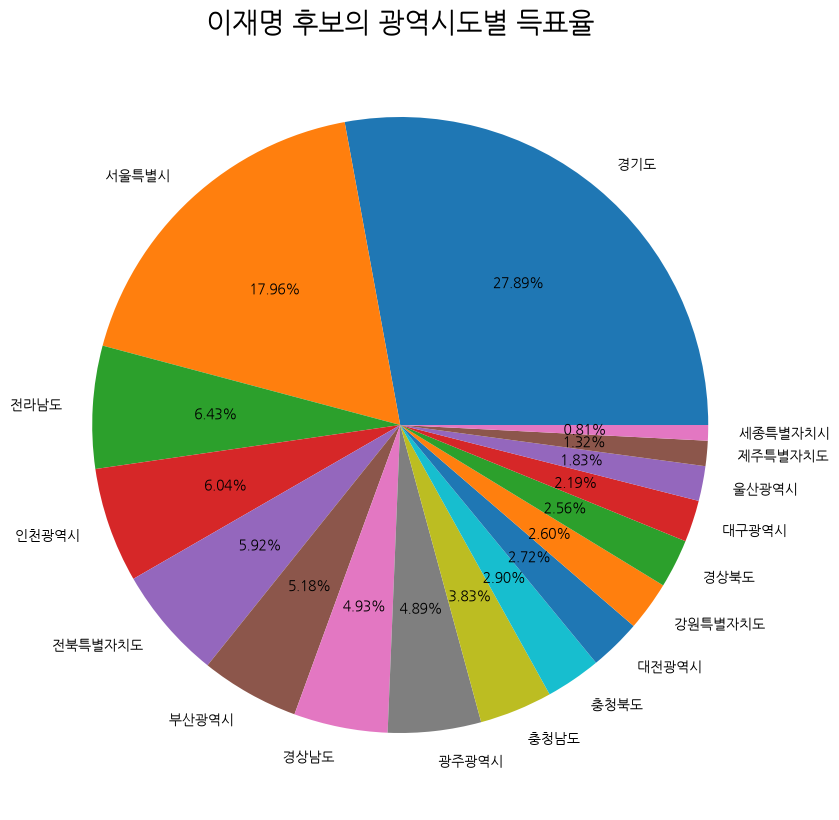

In [53]:
elec_이재명 = \
	election.pivot_table(
		'이재명',
		index='광역시도',
		aggfunc='sum'
	)

elec_이재명 = \
	elec_이재명.sort_values(
		by='이재명',
		ascending=False
	)

elec_이재명['이재명'].plot(
    kind='pie',
    figsize=(10, 10),
    autopct="%.2f%%"
)

plt.title('이재명 후보의 광역시도별 득표율', size=20)
plt.ylabel('')
plt.show()

---
#### 이재명 후보의 서울 득표 Top5

In [68]:
election_seoul = election[election.광역시도 == "서울특별시"]
election_seoul_이재명 = \
	election_seoul.sort_values(
		by='이재명',
		ascending=False
	)[['시군구', '이재명']].set_index('시군구')
election_seoul_이재명.head(10)

,이재명
시군구,
강서구,196256
송파구,191678
노원구,176604
은평구,171417
관악구,171149
강동구,160645
성북구,152624
양천구,143686
구로구,139034


In [71]:
# 기타 구성하기
election_seoul_이재명_etc = election_seoul_이재명.iloc[5:,].sum()
election_seoul_이재명_etc

이재명    2198355
dtype: int64

In [72]:
# top5 구성하고 기타 추가하기
election_seoul_이재명 = election_seoul_이재명.head()
election_seoul_이재명.loc['기타'] = election_seoul_이재명_etc
election_seoul_이재명

,이재명
시군구,
강서구,196256
송파구,191678
노원구,176604
은평구,171417
관악구,171149
기타,2198355


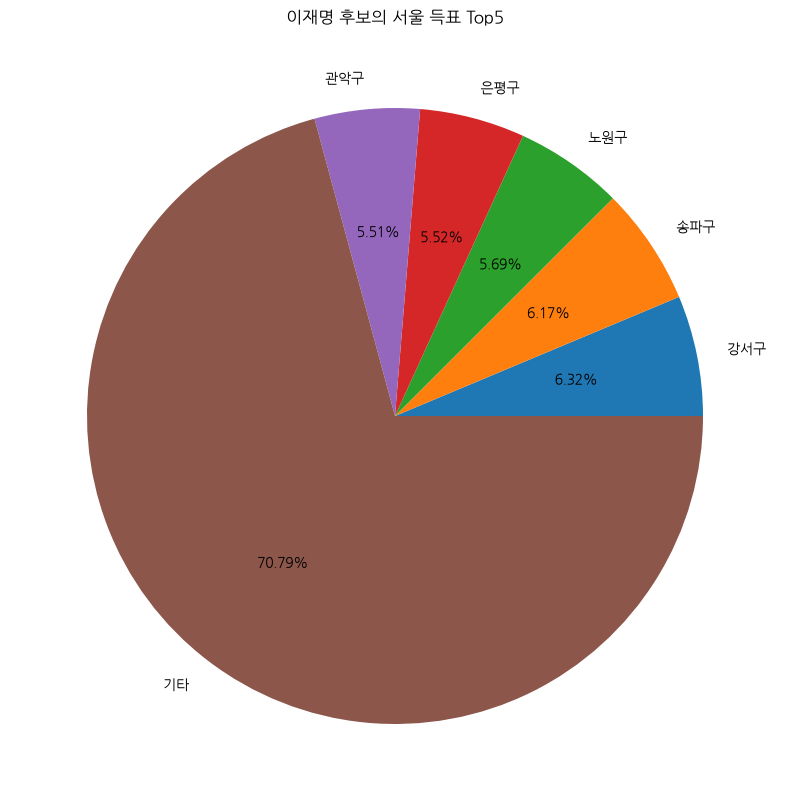

In [74]:
election_seoul_이재명['이재명'].plot(
    kind='pie',
    figsize=(10, 10),
    autopct = '%.2f%%'
)

plt.title('이재명 후보의 서울 득표 Top5')
plt.ylabel("")

plt.show()

---
#### 대선주자 출생지별 득표율 분석

In [77]:
# 이재명 후보의 출생지는 경상북도 안동시 
pob_이재명 = election[election.시군구 == '안동시']
pob_이재명

,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio
211,경상북도,안동시,136331,108216,33560,65739,7050,106349,98.27


In [78]:
# 기타 컬럼 생성
pob_이재명['기타'] = pob_이재명.투표수 - pob_이재명.electionSum
pob_이재명

C:\Users\tjoeun\AppData\Local\Temp\ipykernel_3964\223915281.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pob_이재명['기타'] = pob_이재명.투표수 - pob_이재명.electionSum


,광역시도,시군구,선거인수,투표수,이재명,김문수,이준석,electionSum,electionRatio,기타
211,경상북도,안동시,136331,108216,33560,65739,7050,106349,98.27,1867


In [80]:
# 데이터 선택
pob_이재명 = pob_이재명[['이재명','김문수','이준석','기타']]
pob_이재명 = pob_이재명.T

In [82]:
pob_이재명.columns = ['득표수']
pob_이재명

,득표수
이재명,33560
김문수,65739
이준석,7050
기타,1867


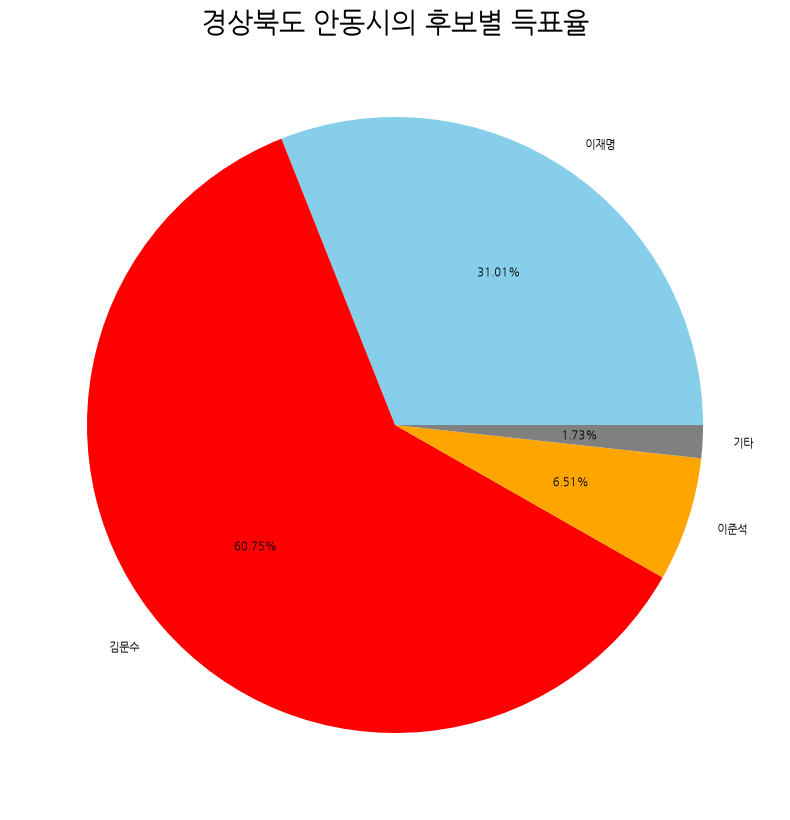

In [ ]:
plt.rcParams['font.size'] = 8 # 폰트 사이즈 
pob_이재명.득표수.plot(
    kind='pie',
    figsize=(10, 10),
    autopct = '%.2f%%',
    colors=['skyblue', 'red', 'orange', 'grey']
)

plt.title('경상북도 안동시의 후보별 득표율', size=20)
plt.ylabel("")

plt.show()

---
#### 투표수가 가장 많은 5지역(광역시도)의 각 후보별 득표수를 막대그래프로 표현하기

In [95]:
# 투표수가 가장 많은 5지역 구하기
top5Area = elec_sum_order.index[0:4+1]
top5Area

Index(['경기도', '서울특별시', '부산광역시', '경상남도', '인천광역시'], dtype='object', name='광역시도')

In [98]:
top5 = \
	election.pivot_table(
		['이재명', '김문수', '이준석', '투표수'],
		index='광역시도',
		aggfunc='sum'
	).sort_values(by='투표수', ascending=False).head()
top5

,김문수,이재명,이준석,투표수
광역시도,,,,
경기도,3504620,4821148,816435,9297448
서울특별시,2738405,3105459,655346,6641606
부산광역시,1146238,895213,168473,2245755
경상남도,1123843,851733,161579,2179989
인천광역시,776952,1044295,176739,2035355


In [99]:
# 필요한 컬럼 추출
top5 = top5[['이재명','김문수','이준석']]
top5

,이재명,김문수,이준석
광역시도,,,
경기도,4821148,3504620,816435
서울특별시,3105459,2738405,655346
부산광역시,895213,1146238,168473
경상남도,851733,1123843,161579
인천광역시,1044295,776952,176739


In [100]:
top5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 경기도 to 인천광역시
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   이재명     5 non-null      int64
 1   김문수     5 non-null      int64
 2   이준석     5 non-null      int64
dtypes: int64(3)
memory usage: 160.0+ bytes


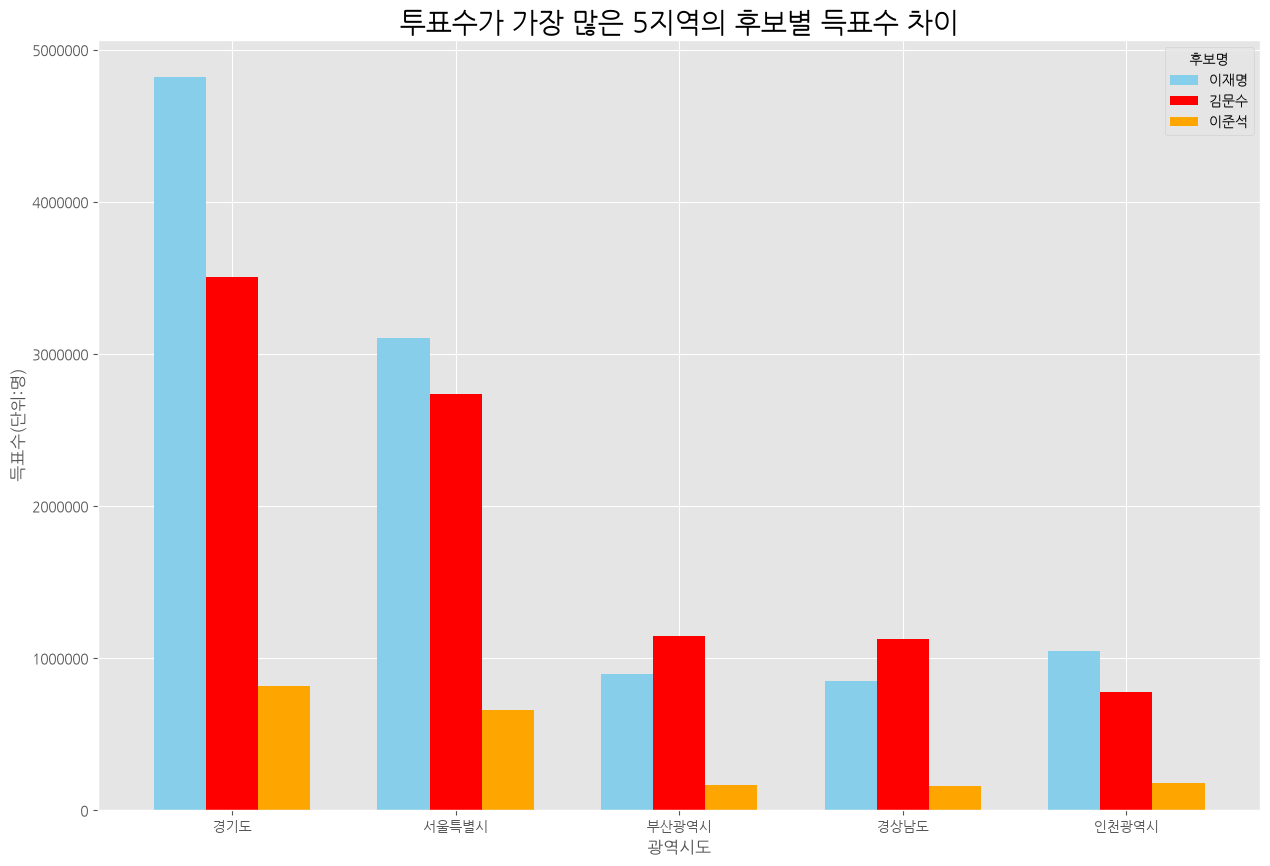

In [109]:
plt.style.use('ggplot')
top5.plot(
    kind='bar',
    figsize=(15, 10),
    rot=0,
    width=0.7, # 막대간의 간격 
    color=['skyblue', 'red', 'orange'] 
)

# Y축의 지수표시 막기
plt.ticklabel_format(
    axis='y',
    useOffset=False,
    style='plain'
)

plt.title("투표수가 가장 많은 5지역의 후보별 득표수 차이", size=20)
plt.xlabel('광역시도')
plt.ylabel('득표수(단위:명)')
plt.legend(title='후보명')

plt.show()